# Model Training and Evaluation Report

The trained baseline logistic-regression model shows weak but usable signal on the processed semiconductor sensor data. The held-out test set contains 314 wafers with a 6.7% fail rate, so precision-recall behavior and false-pass counts carry more weight than accuracy.

At the default 0.5 threshold, the model reaches 0.656 ROC-AUC and 0.160 PR-AUC. It identifies 5 of 21 failing wafers and leaves 16 false passes, which makes the default threshold too permissive for high-cost failure escape review. The cost-sensitive threshold analysis moves the operating point toward higher recall and lowers configured expected cost from 197 to 173.

## Analysis Inputs

The analysis uses the processed train/test split, the baseline model configuration, and the cost matrix captured in `configs/config.yaml` and `configs/cost_config.yaml`. The generated model and report artifacts are written under `models/` and `reports/`, which keeps the evaluation tied to the exact configuration and data split summarized below.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

sys.path.insert(0, "../src")

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

from yield_risk.config import load_config, load_cost_config
from yield_risk.evaluate import compute_metrics, format_report, save_metrics
from yield_risk.importance import extract_lr_coefficients
from yield_risk.model import build_baseline_pipeline, cross_validate_model, train_model
from yield_risk.thresholding import find_optimal_threshold, threshold_cost_curve

ROOT = Path("..").resolve()

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Configuration

The configuration fixes the random seed, a 20% held-out test split, five cross-validation folds, and preprocessing filters for missingness, variance, and correlation. The cost matrix assigns a false pass ten times the cost of a false fail, so threshold selection is evaluated against failure escapes rather than overall classification accuracy.

In [2]:
cfg = load_config(ROOT / "configs" / "config.yaml")
cost_cfg = load_cost_config(ROOT / "configs" / "cost_config.yaml")

processed_dir = ROOT / "data" / "processed"
models_dir = ROOT / "models"
reports_dir = ROOT / "reports"
figures_dir = reports_dir / "figures"

config_summary = pd.DataFrame(
    [
        ("random_seed", cfg.run.random_seed),
        ("test_size", cfg.run.test_size),
        ("cv_folds", cfg.run.cv_folds),
        ("missing_threshold", cfg.run.missing_threshold),
        ("variance_threshold", cfg.run.variance_threshold),
        ("correlation_threshold", cfg.run.correlation_threshold),
        ("false_fail_cost", cost_cfg.cost_matrix.false_fail),
        ("false_pass_cost", cost_cfg.cost_matrix.false_pass),
        ("threshold_low", cost_cfg.threshold_search.low),
        ("threshold_high", cost_cfg.threshold_search.high),
        ("threshold_steps", cost_cfg.threshold_search.steps),
    ],
    columns=["setting", "value"],
)
config_summary

,setting,value
0,random_seed,42.00
1,test_size,0.20
2,cv_folds,5.00
3,missing_threshold,0.60
4,variance_threshold,0.01
5,correlation_threshold,0.95
6,false_fail_cost,1.00
7,false_pass_cost,10.00
8,threshold_low,0.01
9,threshold_high,0.99


The configured review is conservative in two ways: model quality is estimated both by cross-validation and by a held-out test set, and the decision threshold is judged with an explicit false-pass penalty. This matters because the class balance is highly skewed toward passing wafers.

## Train/Test Population

The processed data contain 1,253 training rows and 314 test rows across 198 sensor features. Failure prevalence is nearly identical in both splits, with a 6.62% train fail rate and a 6.69% test fail rate, so the held-out test set is representative of the rare-failure regime seen during fitting.

In [3]:
train_path = ROOT / "data" / "processed" / "train.csv"
test_path = ROOT / "data" / "processed" / "test.csv"
missing_paths = [path for path in [train_path, test_path] if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Processed train/test data are required. Missing: "
        + ", ".join(str(path) for path in missing_paths)
    )

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sensor_cols = [column for column in train.columns if column.startswith("sensor_")]
if not sensor_cols:
    raise ValueError("No sensor_* columns found in processed training data.")

X_train = train[sensor_cols]
y_train = train["label"]
X_test = test[sensor_cols]
y_test = test["label"].to_numpy()

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(train), len(test)],
        "fail_rate": [y_train.mean(), test["label"].mean()],
        "sensor_count": [len(sensor_cols), len(sensor_cols)],
    }
)
split_summary

,split,rows,fail_rate,sensor_count
0,train,1253,0.066241,198
1,test,314,0.066879,198


The low failure rate means a model can appear stable while missing most failures. The empirical interpretation therefore centers on ROC-AUC, PR-AUC, recall, false passes, and cost-sensitive threshold behavior.

## Cross-Validation and Fitting

The baseline model is a standardized, class-balanced logistic regression. Cross-validation gives a mean ROC-AUC of 0.587 with a standard deviation of 0.070 and a mean F1 of 0.146 with a standard deviation of 0.072. The variation across folds indicates limited signal strength rather than a robust separator.

In [4]:
pipeline = build_baseline_pipeline(cfg.run.random_seed)
cv_results = cross_validate_model(
    pipeline,
    X_train,
    y_train,
    cfg.run.cv_folds,
    cfg.run.random_seed,
)

cv_summary = pd.DataFrame(
    {
        "metric": ["ROC-AUC", "F1"],
        "mean": [
            cv_results["test_roc_auc"].mean(),
            cv_results["test_f1"].mean(),
        ],
        "std": [
            cv_results["test_roc_auc"].std(),
            cv_results["test_f1"].std(),
        ],
    }
)
cv_summary

,metric,mean,std
0,ROC-AUC,0.587123,0.069553
1,F1,0.145874,0.071552


In [5]:
pipeline = train_model(pipeline, X_train, y_train)

models_dir.mkdir(parents=True, exist_ok=True)
model_path = ROOT / "models" / "baseline_lr.joblib"
joblib.dump(pipeline, model_path)

print(f"Saved trained baseline model to {model_path}")

Saved trained baseline model to C:\Users\Virgil\Code\semiconductor-yield-root-cause\models\baseline_lr.joblib


Cross-validation supports only a modest modeling claim: the sensor set contains some predictive information, but the baseline is not strong enough to support high-confidence automated disposition. Downstream explanations should therefore be interpreted as triage evidence rather than definitive process diagnosis.

## Held-Out Test Performance

On the held-out test set, ROC-AUC rises to 0.656 while PR-AUC remains low at 0.160. Precision is 0.119 and recall is 0.238 at the default 0.5 threshold, meaning the model catches 5 of 21 failing wafers while flagging 37 passing wafers as fail.

In [6]:
y_prob = pipeline.predict_proba(X_test)[:, 1]
metrics = compute_metrics(y_test, y_prob)

reports_dir.mkdir(parents=True, exist_ok=True)
metrics_path = reports_dir / "baseline_metrics.json"
save_metrics(metrics, metrics_path)

print(format_report(metrics))
print(f"\nSaved metrics to {metrics_path}")

=== Baseline Model Evaluation ===
ROC AUC:    0.656
PR AUC:     0.160
Precision:  0.119
Recall:     0.238
F1 Score:   0.159

Confusion Matrix:
              Pred Pass  Pred Fail
Actual Pass        256         37
Actual Fail         16          5

Saved metrics to C:\Users\Virgil\Code\semiconductor-yield-root-cause\reports\baseline_metrics.json


In [7]:
cm = metrics.confusion_matrix
confusion_df = pd.DataFrame(
    cm,
    index=["Actual pass", "Actual fail"],
    columns=["Predicted pass", "Predicted fail"],
)
false_pass = cm[1][0]
false_fail = cm[0][1]

print(f"False pass count: {false_pass}")
print(f"False fail count: {false_fail}")
confusion_df

False pass count: 16
False fail count: 37


,Predicted pass,Predicted fail
Actual pass,256,37
Actual fail,16,5


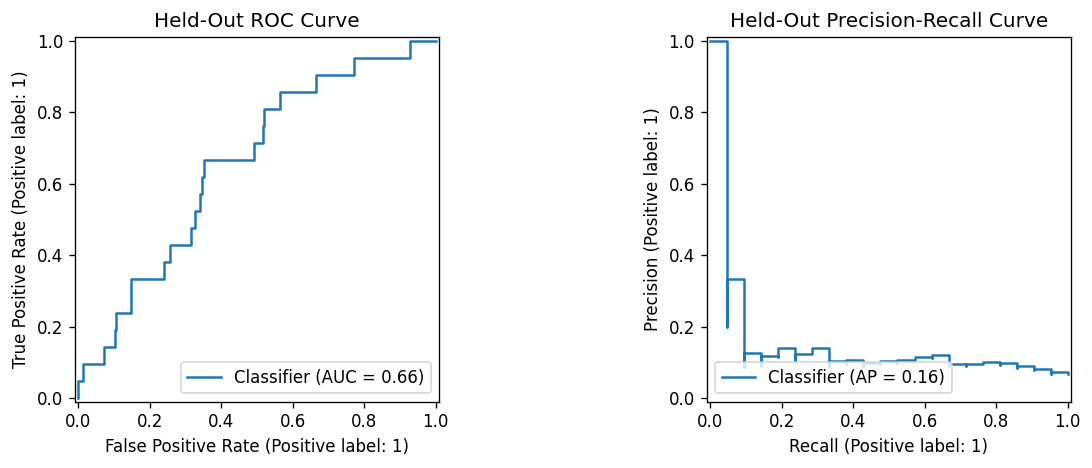

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0])
axes[0].set_title("Held-Out ROC Curve")
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title("Held-Out Precision-Recall Curve")
plt.tight_layout()

The default-threshold confusion matrix exposes the main operational weakness: 16 failing wafers are predicted as pass. Because the configured false-pass cost is high, the threshold analysis below is the more relevant view of the model as a decision-support pipeline component.

## Cost-Sensitive Threshold Behavior

The cost curve evaluates the same probability scores under the configured false-pass and false-fail penalties. The minimum expected cost occurs at a threshold of 0.070, far below the default 0.5 threshold, which shifts the model toward catching more failures at the expense of more false-fail review load.

Lowest-cost threshold: 0.070; expected cost: 173.00
Default-threshold expected cost: 197.00
False pass count at cost-sensitive threshold: 7
False fail count at cost-sensitive threshold: 103


,Predicted pass,Predicted fail
Actual pass,190,103
Actual fail,7,14


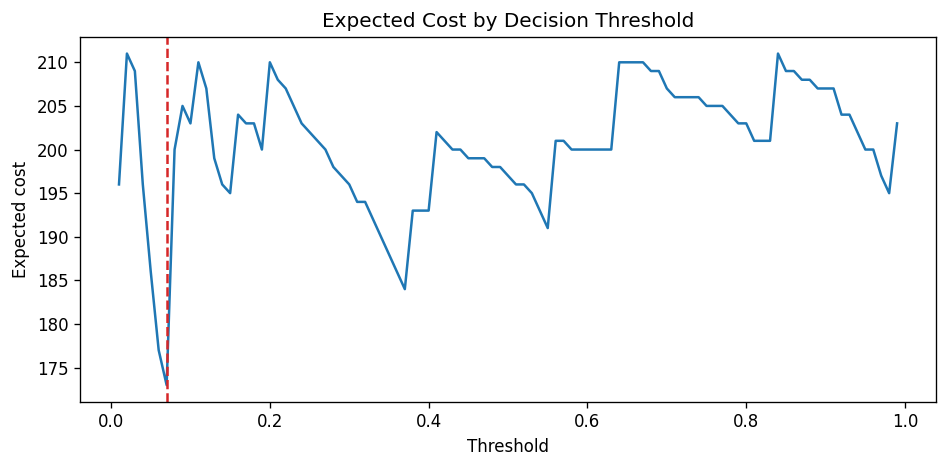

In [9]:
cost_curve = threshold_cost_curve(
    y_test,
    y_prob,
    cost_cfg.cost_matrix,
    cost_cfg.threshold_search,
)
optimal_threshold = find_optimal_threshold(
    y_test,
    y_prob,
    cost_cfg.cost_matrix,
    cost_cfg.threshold_search,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cost_curve["threshold"], cost_curve["expected_cost"])
ax.axvline(optimal_threshold.threshold, color="tab:red", linestyle="--")
ax.set_title("Expected Cost by Decision Threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Expected cost")
plt.tight_layout()

optimal_pred = (y_prob >= optimal_threshold.threshold).astype(int)
optimal_confusion_df = pd.crosstab(
    pd.Series(y_test, name="Actual"),
    pd.Series(optimal_pred, name="Predicted"),
    dropna=False,
).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
optimal_confusion_df.index = ["Actual pass", "Actual fail"]
optimal_confusion_df.columns = ["Predicted pass", "Predicted fail"]
optimal_false_pass = int(((y_test == 1) & (optimal_pred == 0)).sum())
optimal_false_fail = int(((y_test == 0) & (optimal_pred == 1)).sum())
default_cost = false_pass * cost_cfg.cost_matrix.false_pass + false_fail * cost_cfg.cost_matrix.false_fail

print(
    f"Lowest-cost threshold: {optimal_threshold.threshold:.3f}; "
    f"expected cost: {optimal_threshold.expected_cost:.2f}"
)
print(f"Default-threshold expected cost: {default_cost:.2f}")
print(f"False pass count at cost-sensitive threshold: {optimal_false_pass}")
print(f"False fail count at cost-sensitive threshold: {optimal_false_fail}")
optimal_confusion_df

At the 0.070 threshold, false passes fall from 16 to 7 while false fails rise from 37 to 103. The expected cost improves from 197 at the default threshold to 173 at the cost-sensitive threshold. Empirically, the model is more useful as a high-recall screening aid than as a balanced classifier.

## Linear Feature Importance

The largest logistic-regression coefficients are concentrated in a small group of sensors, led by `sensor_151`, `sensor_205`, `sensor_164`, `sensor_197`, and `sensor_523` by absolute coefficient magnitude. Positive coefficients increase predicted failure probability; negative coefficients reduce it after standardization.

Saved feature importance to C:\Users\Virgil\Code\semiconductor-yield-root-cause\reports\feature_importance.csv


,feature,coefficient,abs_coefficient
0,sensor_151,-2.193362,2.193362
1,sensor_205,2.154402,2.154402
2,sensor_164,-2.150317,2.150317
3,sensor_197,1.659449,1.659449
4,sensor_523,-1.530926,1.530926
5,sensor_059,1.515706,1.515706
6,sensor_155,-1.362073,1.362073
7,sensor_025,1.360444,1.360444
8,sensor_045,1.251715,1.251715
9,sensor_035,-1.242905,1.242905


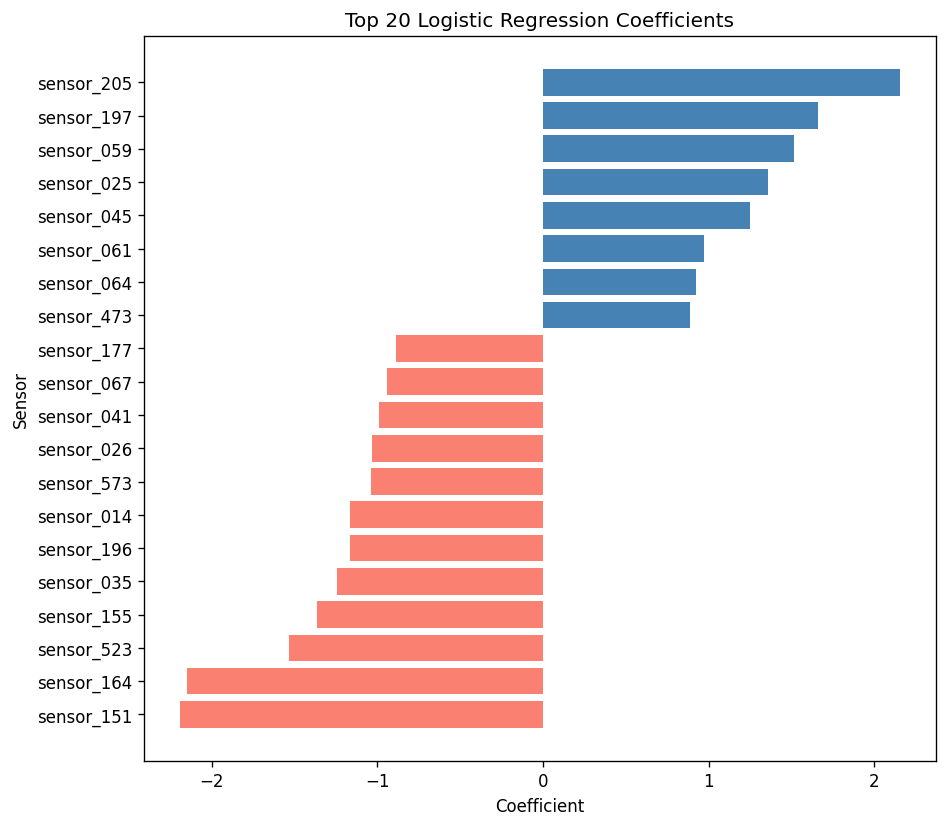

In [10]:
importance_df = extract_lr_coefficients(pipeline, sensor_cols)

importance_path = reports_dir / "feature_importance.csv"
importance_df.to_csv(importance_path, index=False)

top_n = 20
top_features = importance_df.head(top_n).sort_values("coefficient")
colors = ["steelblue" if value >= 0 else "salmon" for value in top_features["coefficient"]]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_features["feature"], top_features["coefficient"], color=colors)
ax.set_title(f"Top {top_n} Logistic Regression Coefficients")
ax.set_xlabel("Coefficient")
ax.set_ylabel("Sensor")
plt.tight_layout()

print(f"Saved feature importance to {importance_path}")
importance_df.head(10)

The coefficient ranking gives an initial model-based sensor view, but it does not establish causality. The strongest coefficients identify where the linear baseline draws decision boundary signal; SHAP analysis in the next report checks whether similar sensors dominate local and global attribution.

## Modeling Assessment

The baseline clears a low bar for empirical signal but not a high bar for autonomous decision-making. It separates failures better than random on the held-out set, yet default-threshold recall is low and PR-AUC remains close to the rare-event baseline. The cost-sensitive threshold improves the configured business objective by reducing false passes, which makes the trained model suitable for root-cause triage experiments and sensor prioritization, not final wafer disposition.